# 05 - Evaluation

Compares train vs. test performance for both models (to check overfitting), inspects feature importance to see whether the Sentinel-2 satellite features actually helped, and plots the confusion matrix for the primary XGBoost model.

In [1]:
# --- Notebook-chaining glue code (added when splitting the original pipeline) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
import joblib

xgb_model = joblib.load("model_xgboost_v2.joblib")
rf_model = joblib.load("model_random_forest_v2.joblib")
xgb_train_pred = joblib.load("train_xgb_train_pred.joblib")
xgb_pred = joblib.load("train_xgb_pred.joblib")
rf_train_pred = joblib.load("train_rf_train_pred.joblib")
rf_pred = joblib.load("train_rf_pred.joblib")
y_train = joblib.load("train_y_train.joblib")
y_test = joblib.load("train_y_test.joblib")
FEATURES = joblib.load("train_features.joblib")
label_encoder = joblib.load("train_label_encoder.joblib")
print("Loaded fitted models, predictions, and metadata from the model training notebook.")

Loaded fitted models, predictions, and metadata from the model training notebook.


In [2]:
# Training vs Test accuracy — detects overfitting
xgb_train_acc = (xgb_train_pred == y_train).mean()
xgb_test_acc = (xgb_pred == y_test).mean()
xgb_train_f1 = f1_score(y_train, xgb_train_pred, average="macro")
xgb_test_f1 = f1_score(y_test, xgb_pred, average="macro")

print(f"XGBoost TRAIN accuracy: {xgb_train_acc:.4f}  | TRAIN macro F1: {xgb_train_f1:.4f}")
print(f"XGBoost TEST accuracy:  {xgb_test_acc:.4f}  | TEST macro F1:  {xgb_test_f1:.4f}")
print(f"Accuracy gap (train - test): {xgb_train_acc - xgb_test_acc:.4f}")

XGBoost TRAIN accuracy: 0.9982  | TRAIN macro F1: 0.9981
XGBoost TEST accuracy:  0.9810  | TEST macro F1:  0.9069
Accuracy gap (train - test): 0.0172


In [3]:
rf_train_acc = (rf_train_pred == y_train).mean()
rf_test_acc = (rf_pred == y_test).mean()
rf_train_f1 = f1_score(y_train, rf_train_pred, average="macro")
rf_test_f1 = f1_score(y_test, rf_pred, average="macro")

print(f"Random Forest TRAIN accuracy: {rf_train_acc:.4f}  | TRAIN macro F1: {rf_train_f1:.4f}")
print(f"Random Forest TEST accuracy:  {rf_test_acc:.4f}  | TEST macro F1:  {rf_test_f1:.4f}")
print(f"Accuracy gap (train - test): {rf_train_acc - rf_test_acc:.4f}")

Random Forest TRAIN accuracy: 0.9913  | TRAIN macro F1: 0.9856
Random Forest TEST accuracy:  0.9785  | TEST macro F1:  0.8771
Accuracy gap (train - test): 0.0129


## Step 7: Feature importance — did the satellite features actually help?

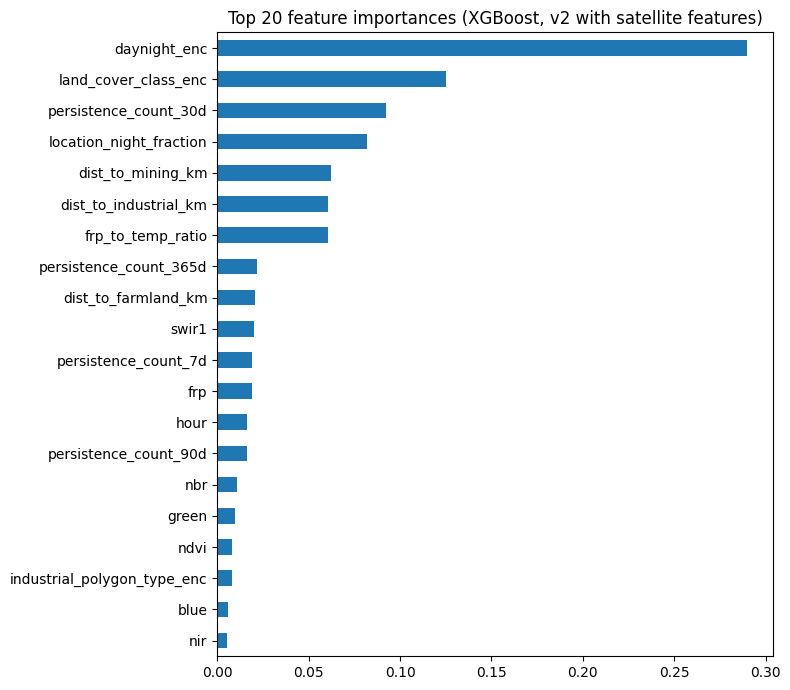

daynight_enc                   0.289614
land_cover_class_enc           0.125037
persistence_count_30d          0.092279
location_night_fraction        0.081630
dist_to_mining_km              0.062123
dist_to_industrial_km          0.060692
frp_to_temp_ratio              0.060481
persistence_count_365d         0.021575
dist_to_farmland_km            0.020596
swir1                          0.020006
persistence_count_7d           0.019110
frp                            0.018965
hour                           0.016200
persistence_count_90d          0.016139
nbr                            0.011011
green                          0.009742
ndvi                           0.008259
industrial_polygon_type_enc    0.007913
blue                           0.005843
nir                            0.005252
dtype: float32

In [4]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
plt.figure(figsize=(8, 7))
importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 feature importances (XGBoost, v2 with satellite features)")
plt.tight_layout()
plt.savefig("feature_importance_v2.png", dpi=150)
plt.show()
importances.head(20)

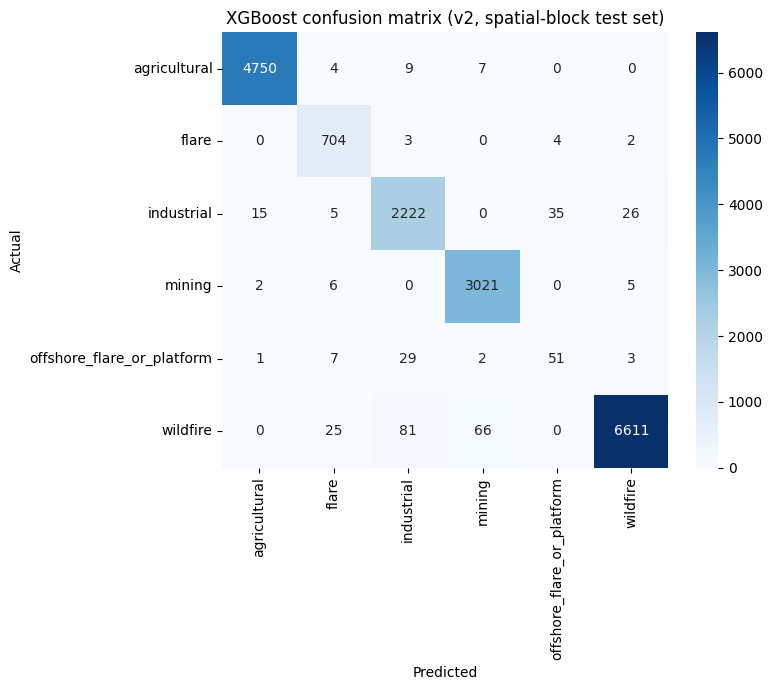

In [5]:
plt.figure(figsize=(8, 7))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("XGBoost confusion matrix (v2, spatial-block test set)")
plt.tight_layout()
plt.savefig("confusion_matrix_v2.png", dpi=150)
plt.show()

## Summary

Compare this v2 macro F1 against your earlier v1 result (built without satellite
features) to see whether Sentinel-2 data actually improved the model — report both
numbers, since showing the improvement (or lack of it) from adding a whole new data
source is a strong methodology point for judges.